# II.1
### Q3

a) $\displaystyle \lim\limits_{n \to \infty} \frac{|2^{-n-1}|}{|2^{-n}|}= \frac{1}{2}$, so $a_n$ converges linearly

b) $\displaystyle \lim\limits_{n \to \infty} \frac{|(n+2)^{-1}|}{|(n+1)^{-1}|} = \lim\limits_{n \to \infty} 1 - \frac{1}{n+2} = 1$, so $a_n$ converges linearly

c) $\displaystyle \lim\limits_{n \to \infty} \frac{|2^{-2^{n+1}}|}{|2^{-2^{n}}|^2} = \lim\limits_{n \to \infty} \frac{2^{-2^{n+1}}}{2^{-2^n*2}} = 1$, so $a_n$ converges quadratically

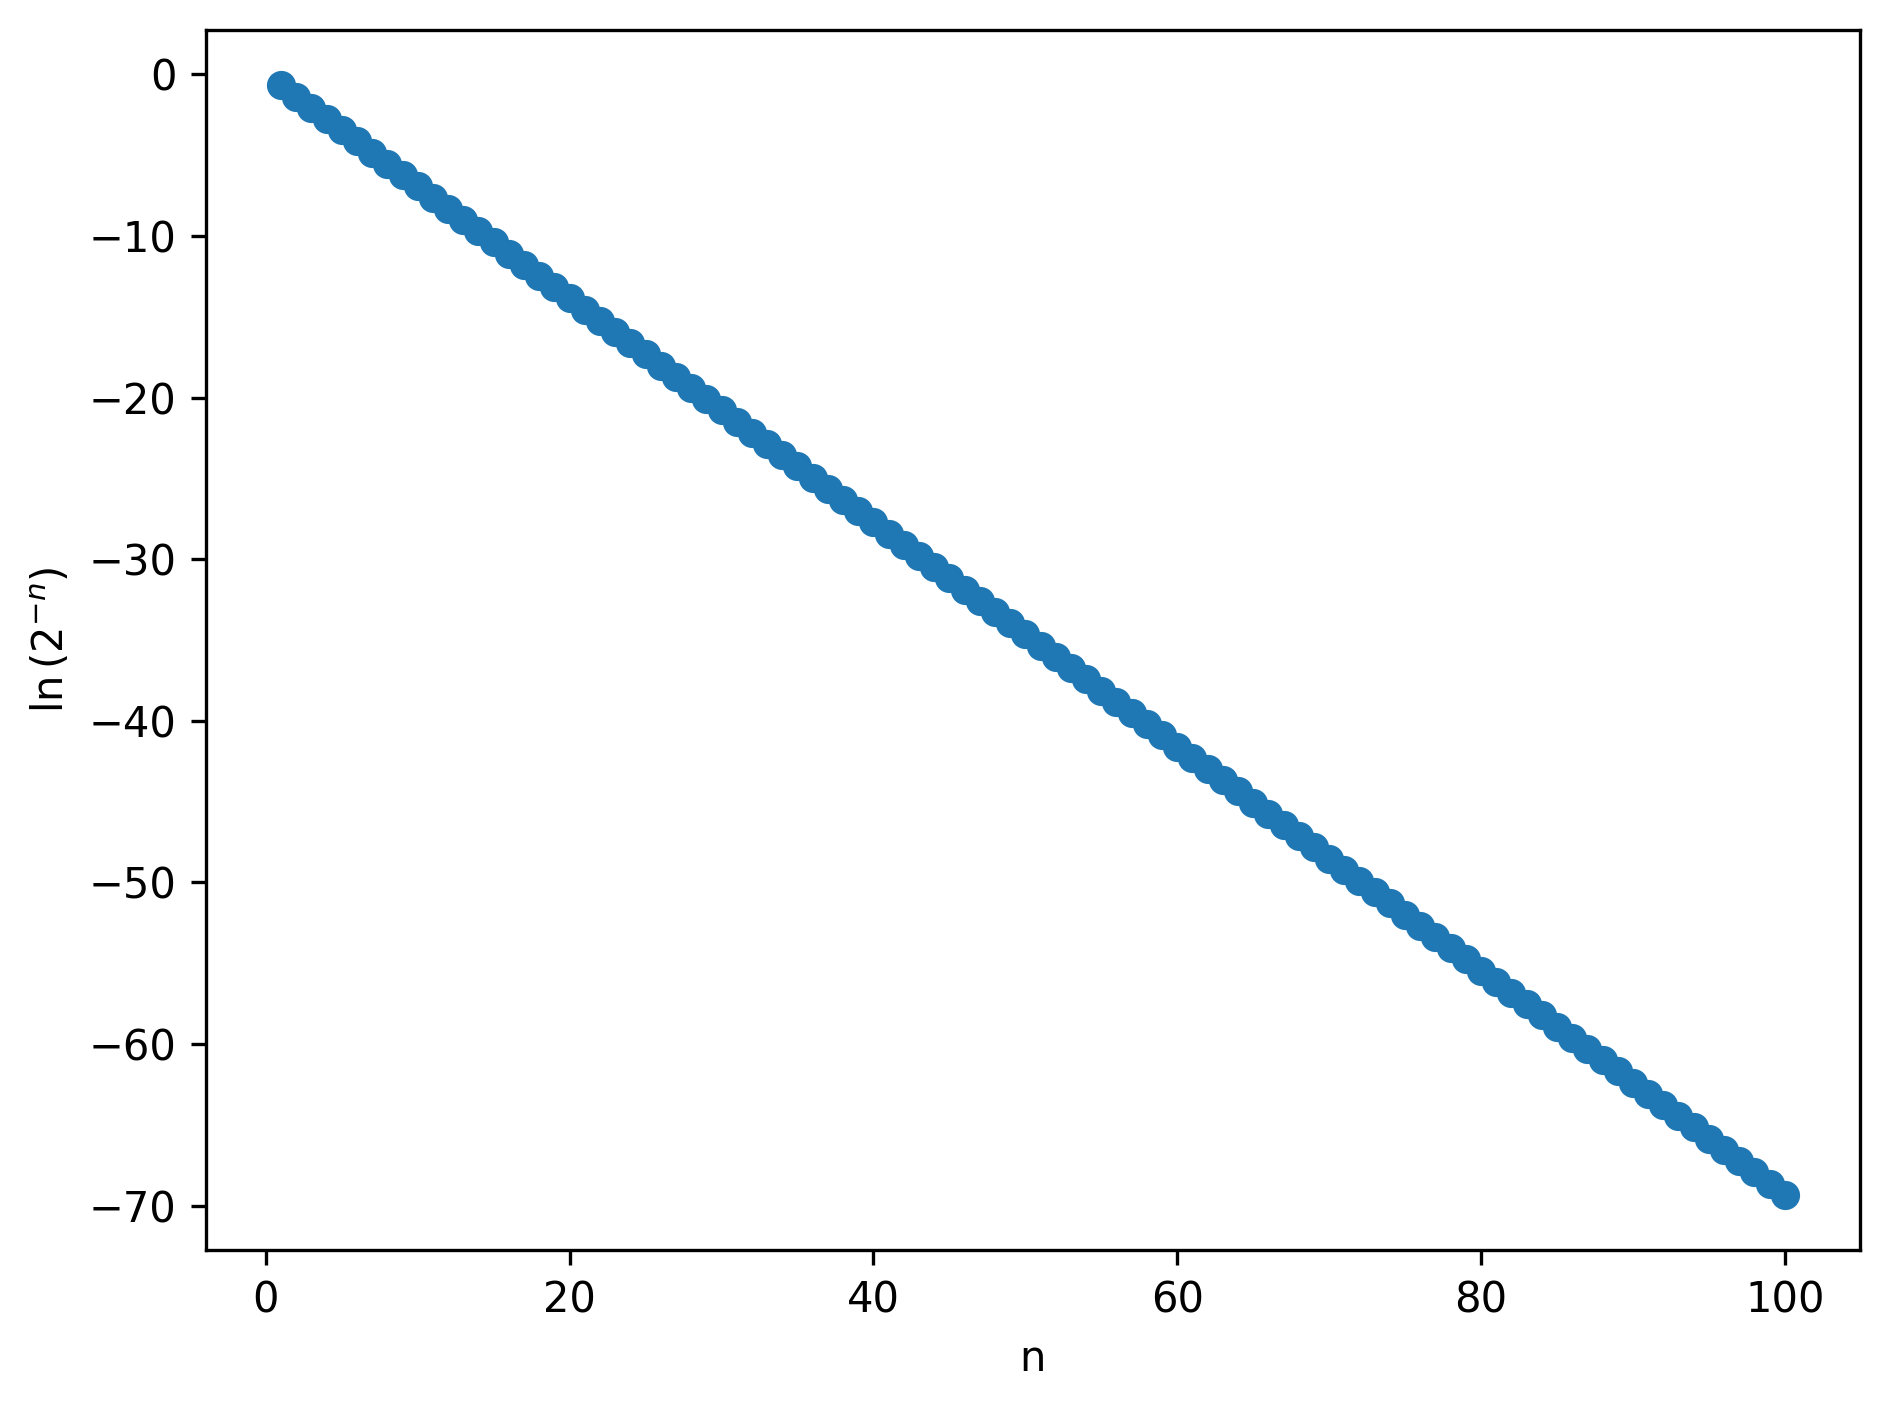

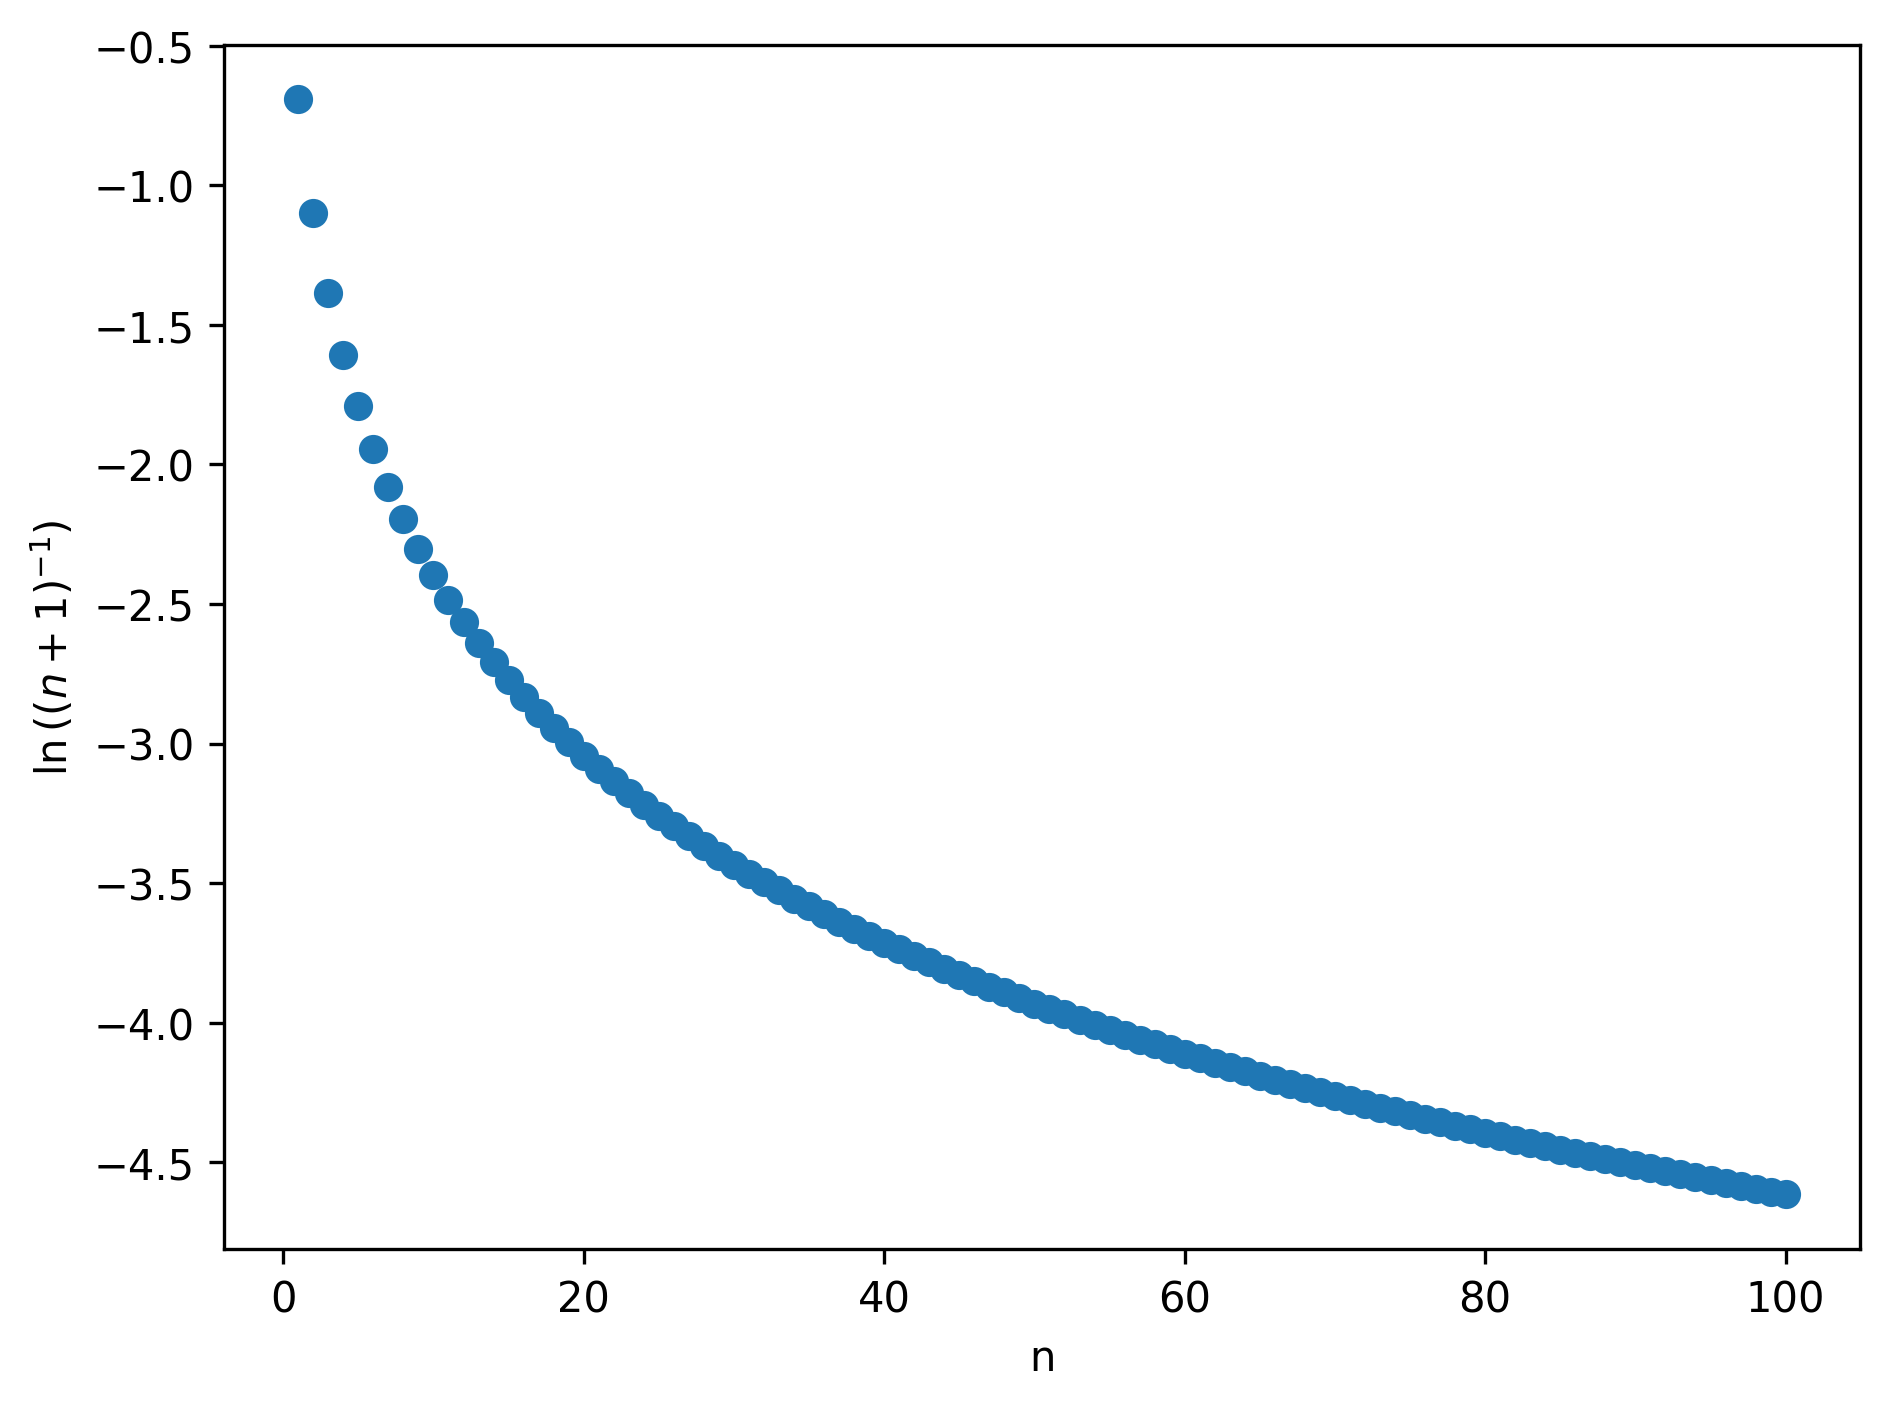

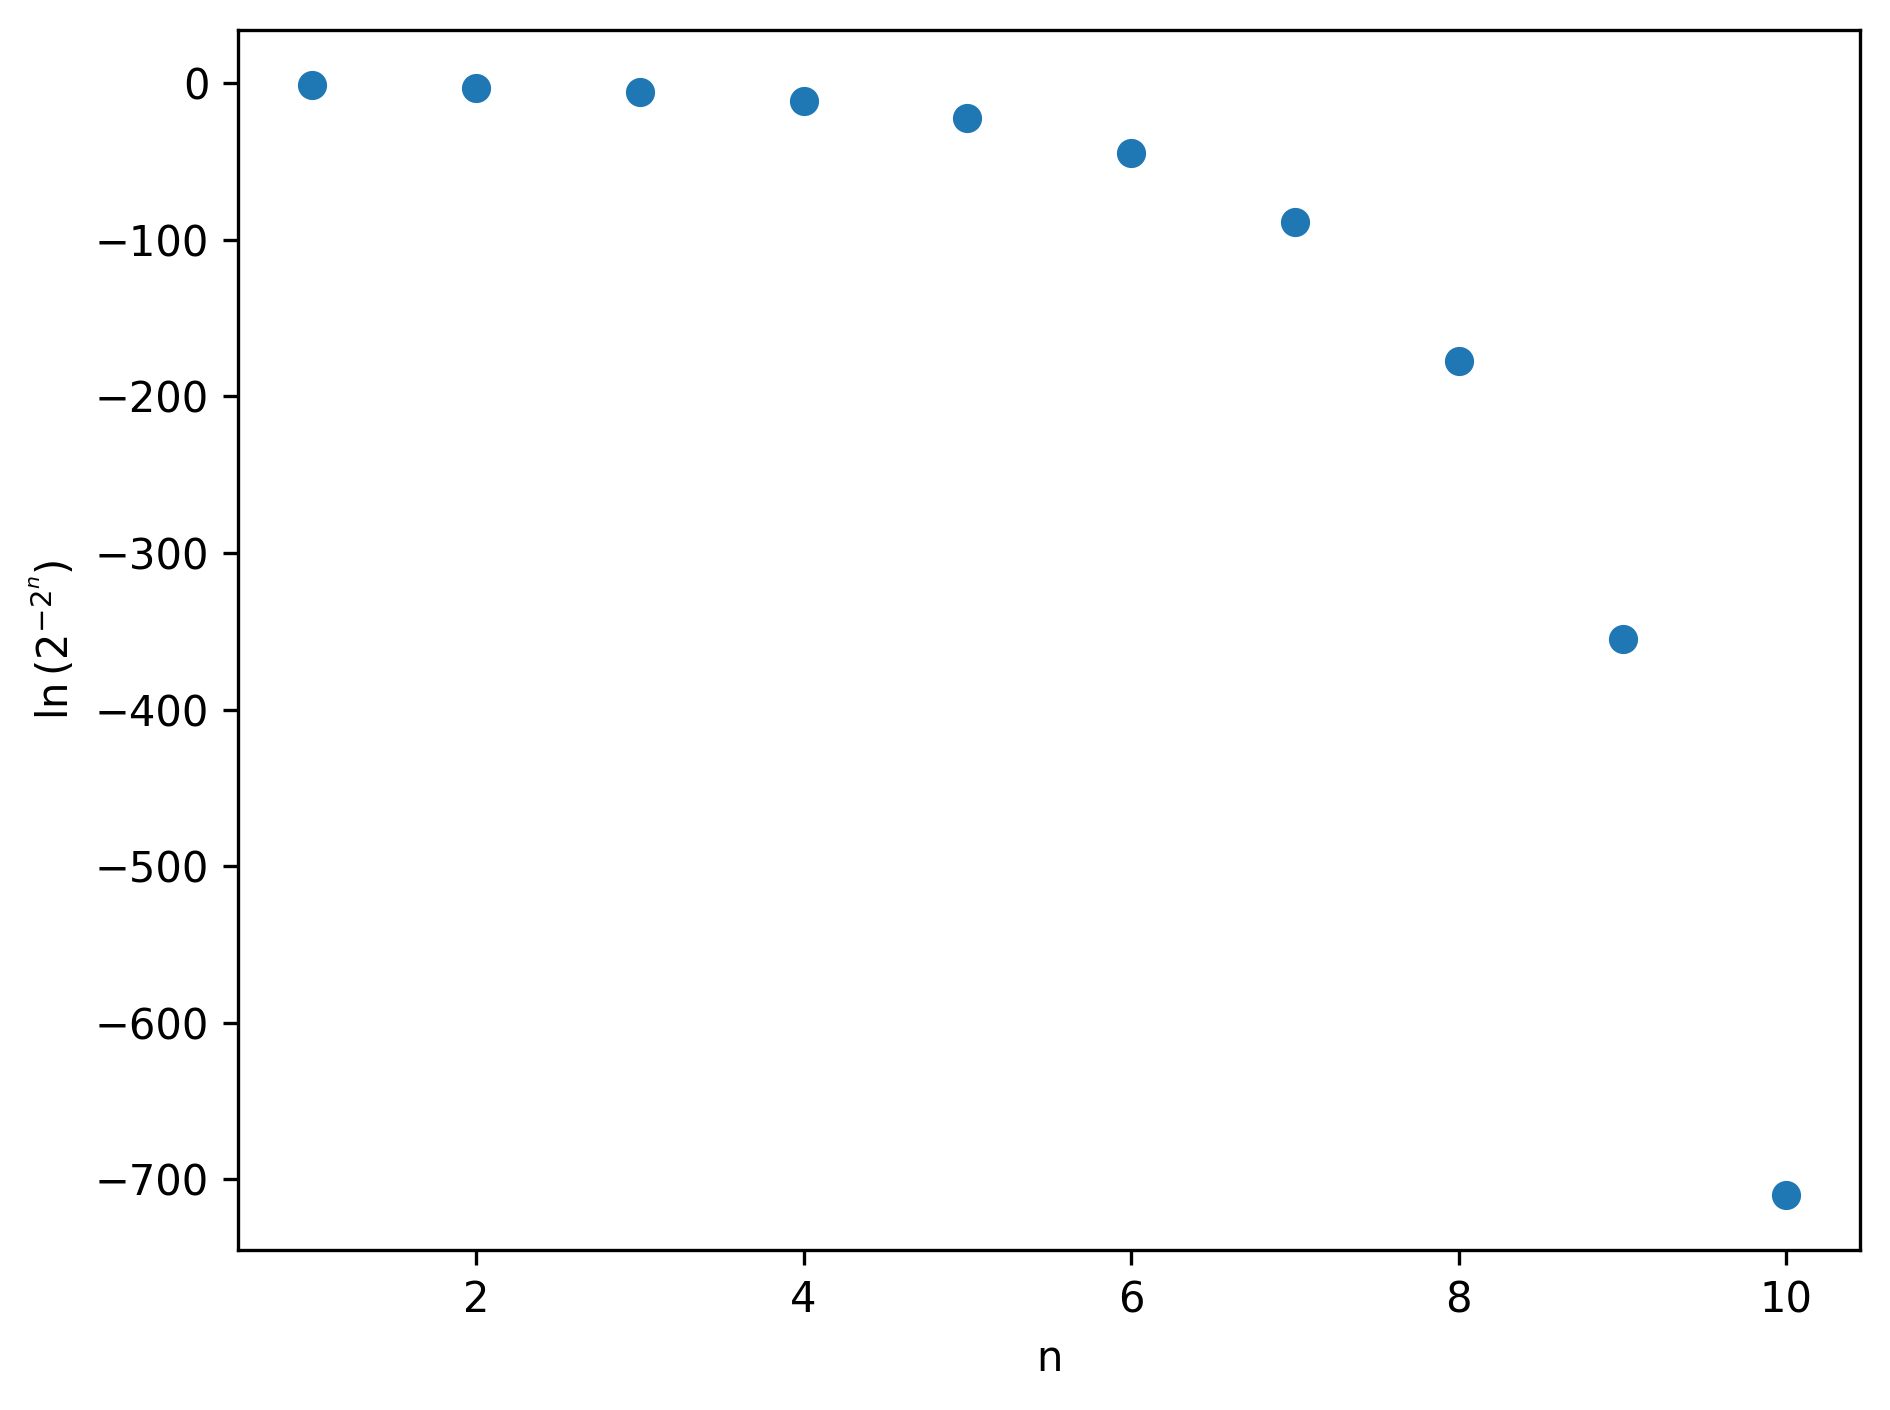

In [1]:
import numpy as np, matplotlib.pyplot as plt

x_values = np.linspace(1, 100, 100)
cx_values = np.linspace(1, 10, 10)

a_values = np.log(2**-(x_values))
b_values = np.log((x_values + 1)**-1)
c_values = np.log(2**(-2**cx_values))

fig, ax = plt.subplots()
ax.set_xlabel("n")
ax.set_ylabel(r"$\ln{(2^{-n})}$")
ax.scatter(x_values, a_values)
plt.gcf().set_dpi(300)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.set_xlabel("n")
ax.set_ylabel(r"$\ln{((n+1)^{-1})}$")
ax.scatter(x_values, b_values)
plt.gcf().set_dpi(300)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.set_xlabel("n")
ax.set_ylabel(r"$\ln{(2^{-2^n})}$")
ax.scatter(cx_values, c_values)
plt.gcf().set_dpi(300)
plt.tight_layout()
plt.show()

<span style="color: SeaGreen; font-size: 32px;">Q3</span>

<span style="color: SeaGreen; font-size: 24px;">

Good work, correct for (a) and (c).

However, (b) converges sublinearly due to the rate being 1 whilst having $q=1$, ultimately meaning the error eventually barely changes. The graph highlights this.

(Also would personally suggest using `ax.plot` rather than `ax.scatter`, as it may make it all easier to see.)

</span>

### Q4

a) The gradient of the function is $\cos{(x)}+1$, which in the range given has an absolute value between 0 and $\displaystyle \cos{(\frac{3\pi}{4})}+1 = 1-\frac{1}{\sqrt{2}} < 1$. Hence X is a contraction, so the theorem applies.

b) $\displaystyle g(2)-g(0) = 20 > 2$, so this function is not a contraction, so the theorem does not apply here.

c) For the contraction mapping theorem to apply, the domain must be bounded (unlike here).

<span style="color: SeaGreen; font-size: 32px;">Q4</span>

<span style="color: SeaGreen; font-size: 24px;">

All correct, though the reasoning is off for (c). The domain need not be bounded, the problem is that even though $|g'(x)| < 1$ for all $x$, the Lipschitz constant/ the supremum of all derivates is $1 \not< 1$, hence not a contraction.

Further, for (a) proving that the Lipschitz constant is $<1$ actually isn't sufficient, showing it is also endomorphic is required.
</span>

### Q5

a) $e_{n+2} \approx M^{q+1}e_n^{q^2}$

$\Rightarrow \ln{(e_{n+1})} \approx \ln{(M)} + q\ln{(e_n)}$

$\ln{(e_{n+2})} \approx (q+1)\ln{(M)} + q^2\ln{(e_n)}$

$\Rightarrow \ln{(e_{n+2})} - q\ln{(e_{n+1})} \approx \ln{(M)}$

By the same argument, $\ln{(e_{n+1})} - q\ln{(e_{n})} \approx \ln{(M)}$

So $\displaystyle q \approx \frac{\ln{(e_{n+2})}-\ln{(e_{n+1})}}{\ln{(e_{n+1})}-\ln{(e_{n})}}$

$\displaystyle M \approx \frac{e_{n+1}}{e_n^q}$

b)

In [2]:
import mpmath
mpmath.mp.dps = 100

k=0
sign = 1 # since (-1)**0 == 1
total = mpmath.mpf("0")

while k <= 10000:
    total += mpmath.mpf("4") * sign / (2*k + 1)
    sign *= -1 # alternate the sign of (-1)**k
    k+=1

a = total

total += mpmath.mpf("4") * sign / (2*k + 1)
sign *= -1 # alternate the sign of (-1)**k
k+=1
b = total

c = b + mpmath.mpf("4") * sign / (2*k + 1)

errors = abs(np.array([a, b, c]) - np.pi)

q = (mpmath.log(errors[2]) - mpmath.log(errors[1])) / (mpmath.log(errors[1]) - mpmath.log(errors[0]))
M = errors[1] / errors[0]**q

print("q = "+str(q))
print("M = "+str(M))

q = 0.9998999759940161117287132212838363980404709936937367453367066658980341455801861332464198855704487126
M = 0.9989792711515440381856375090294376180592486246974024424359246124235809911009048061990798810632948084


$q \approx 1$ so the convergance is roughly linear

c)

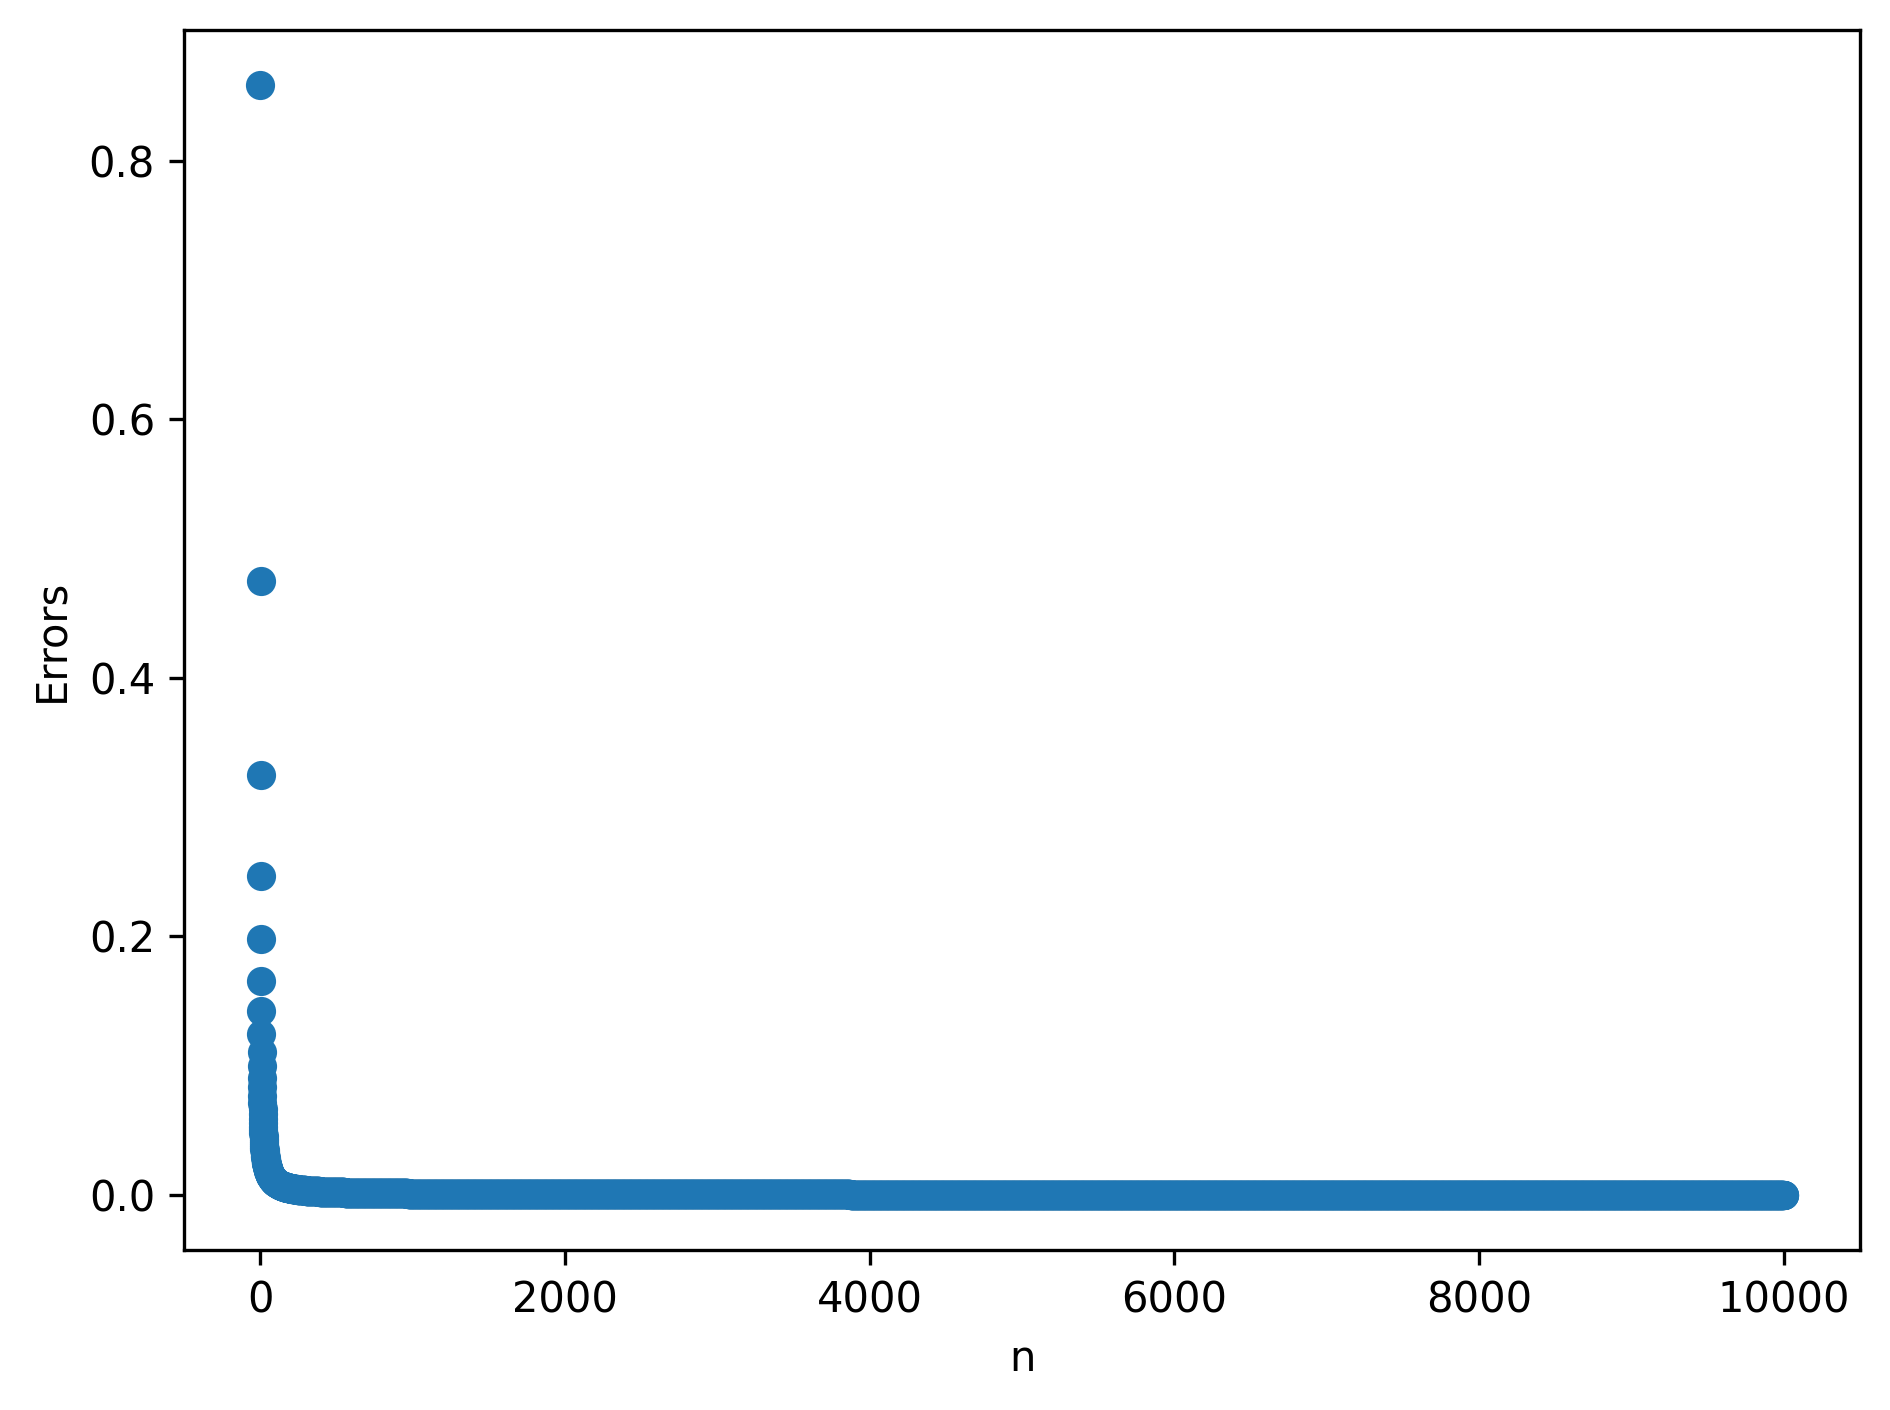

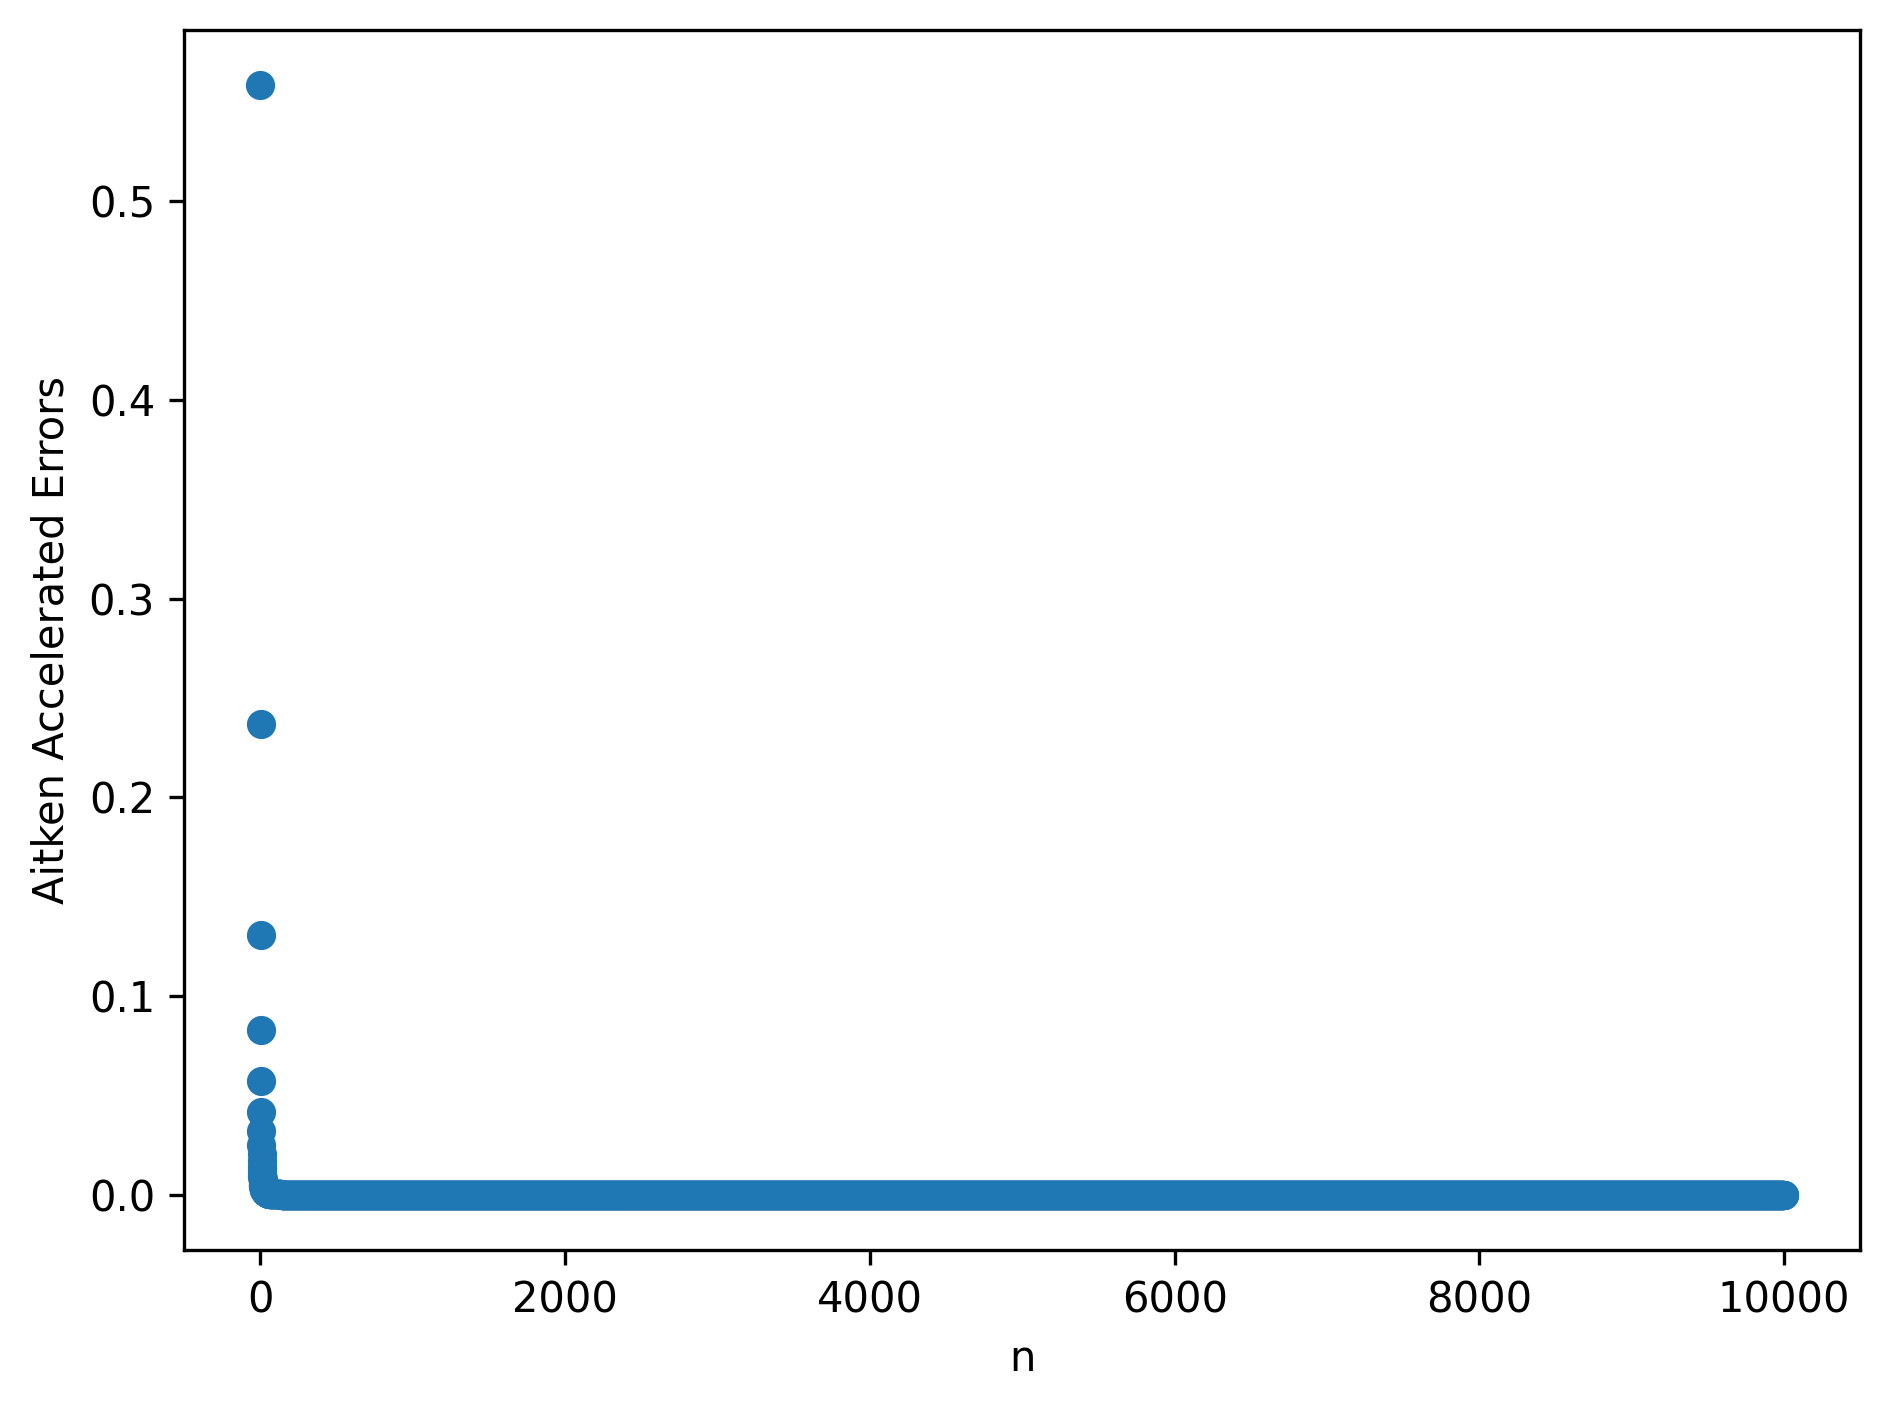

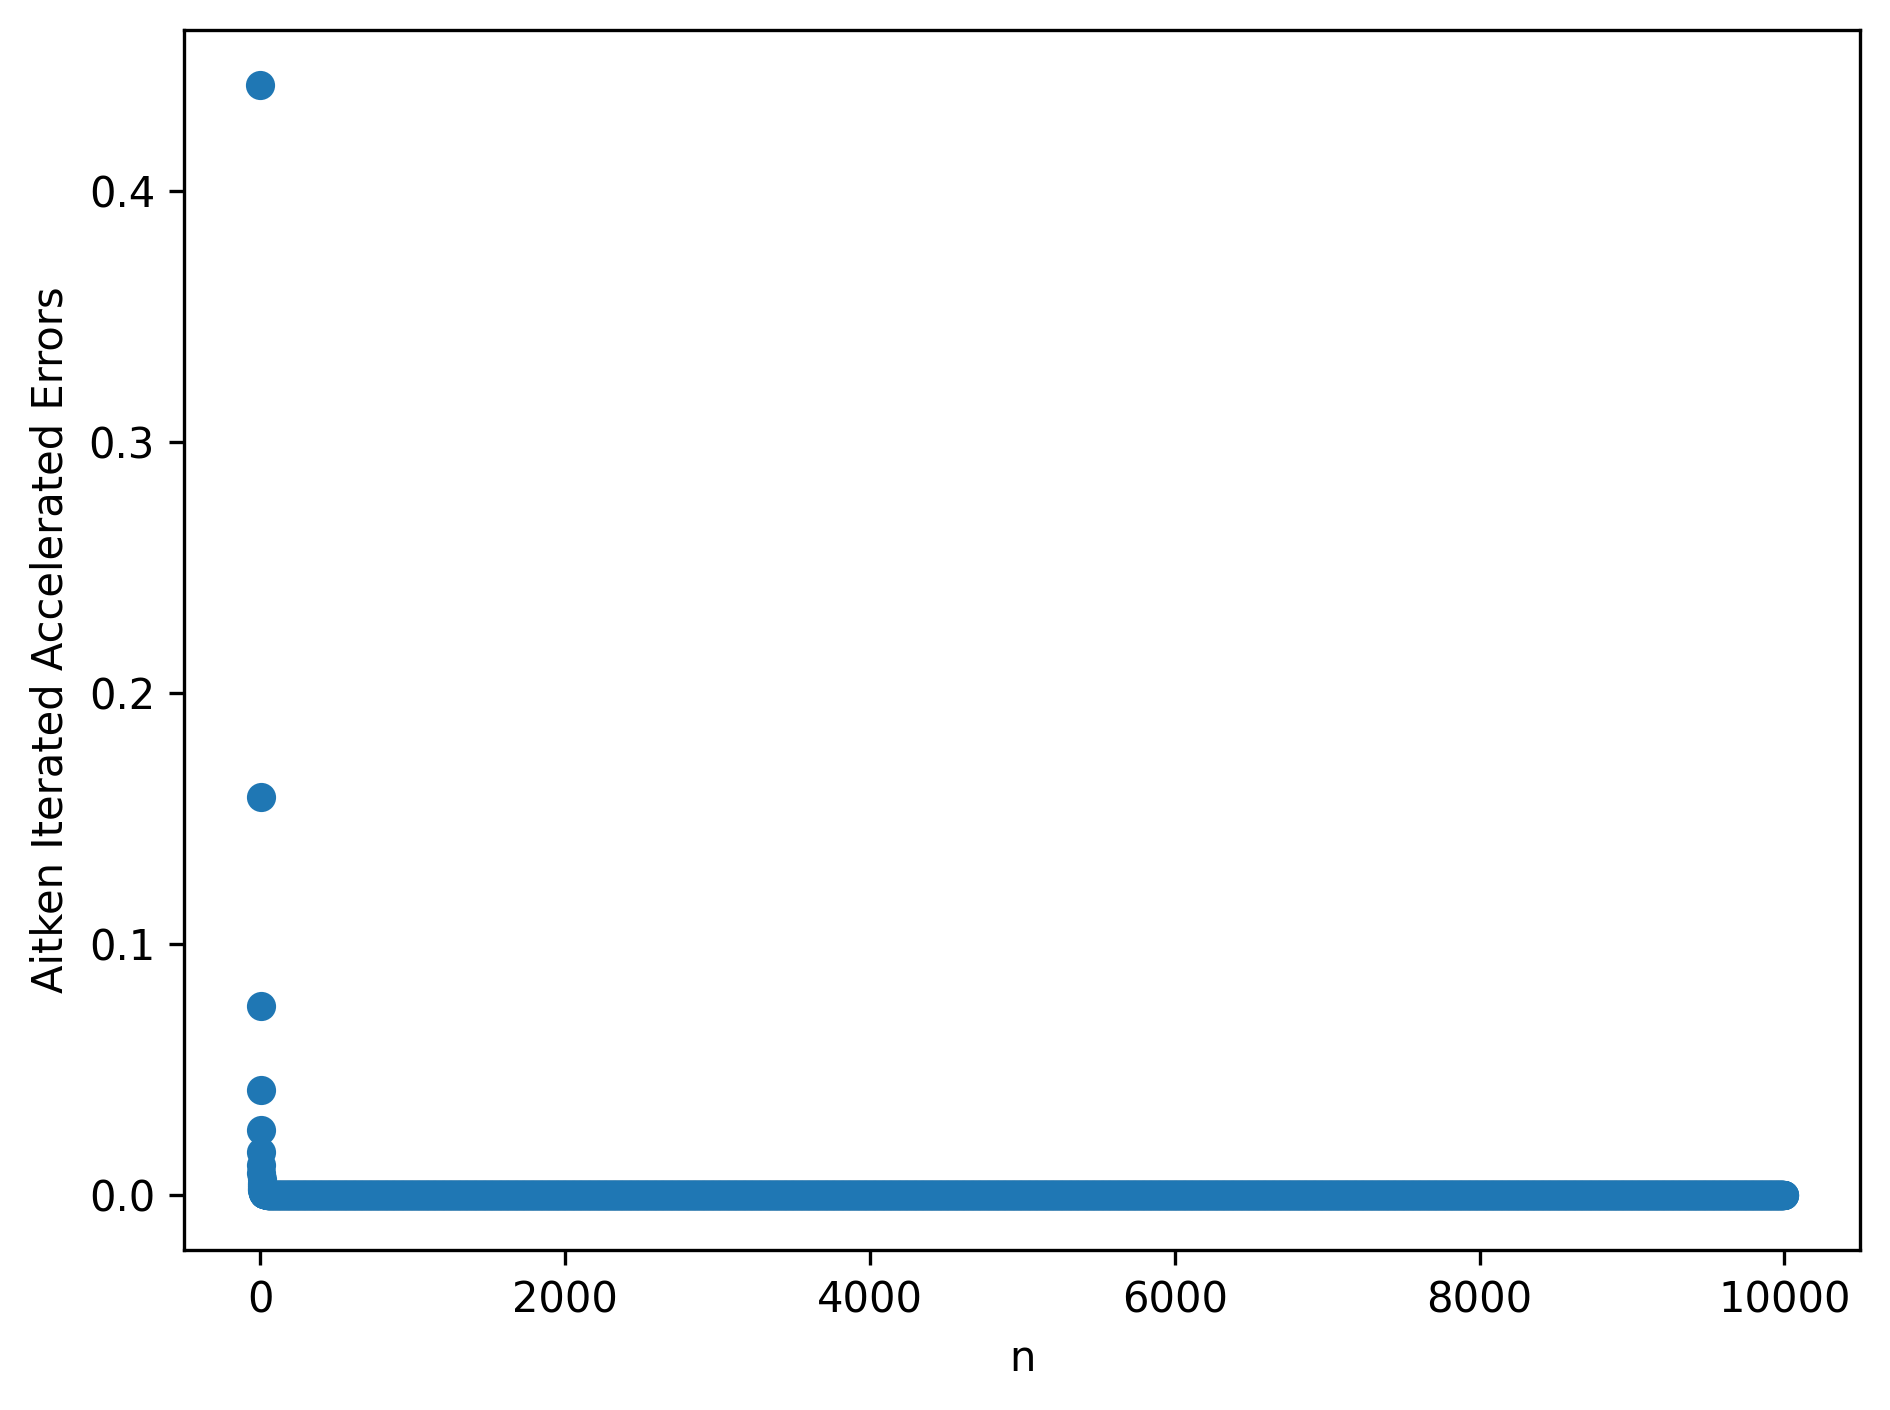

In [3]:
a_values, acc_values, acc_acc_values = np.array([]), np.array([]), np.array([])
k=0
sign = 1 # since (-1)**0 == 1
total = mpmath.mpf("0")

for i in range(2): # needs to work out three terms before the Aitken acceleration can be applied
    total += mpmath.mpf("4") * sign / (2*k + 1)
    sign *= -1 # alternate the sign of (-1)**k
    k+=1
    a_values = np.append(a_values, total)

for i in range(2): # needs to work out 5 terms before the iterated Aitken acceleration can be applied
    total += mpmath.mpf("4") * sign / (2*k + 1)
    sign *= -1 # alternate the sign of (-1)**k
    k+=1
    a_values = np.append(a_values, total)

    acc_values = np.append(acc_values, a_values[-3] - (a_values[-2] - a_values[-1])**2 / (a_values[-1] - 2*a_values[-2] + a_values[-3]))

while k<=10000:
    total += mpmath.mpf("4") * sign / (2*k + 1)
    sign *= -1 # alternate the sign of (-1)**k
    k+=1
    a_values = np.append(a_values, total)

    acc_values = np.append(acc_values, a_values[-3] - (a_values[-2] - a_values[-1])**2 / (a_values[-1] - 2*a_values[-2] + a_values[-3]))
    acc_acc_values = np.append(acc_acc_values, acc_values[-3] - (acc_values[-2] - acc_values[-1])**2 / (acc_values[-1] - 2*acc_values[-2] + acc_values[-3]))


x_values = np.linspace(0, 10000, 10001)
y_values = np.linspace(0, 9998, 9999)
z_values = np.linspace(0, 9996, 9997)

# calculate the errors
a_values, acc_values, acc_acc_values = abs(np.pi - a_values), abs(np.pi - acc_values), abs(np.pi - acc_acc_values)

fig, ax = plt.subplots()
ax.set_xlabel("n")
ax.set_ylabel("Errors")
ax.scatter(x_values, a_values)
plt.gcf().set_dpi(300)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.set_xlabel("n")
ax.set_ylabel("Aitken Accelerated Errors")
ax.scatter(y_values, acc_values)
plt.gcf().set_dpi(300)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.set_xlabel("n")
ax.set_ylabel("Aitken Iterated Accelerated Errors")
ax.scatter(z_values, acc_acc_values)
plt.gcf().set_dpi(300)
plt.tight_layout()
plt.show()

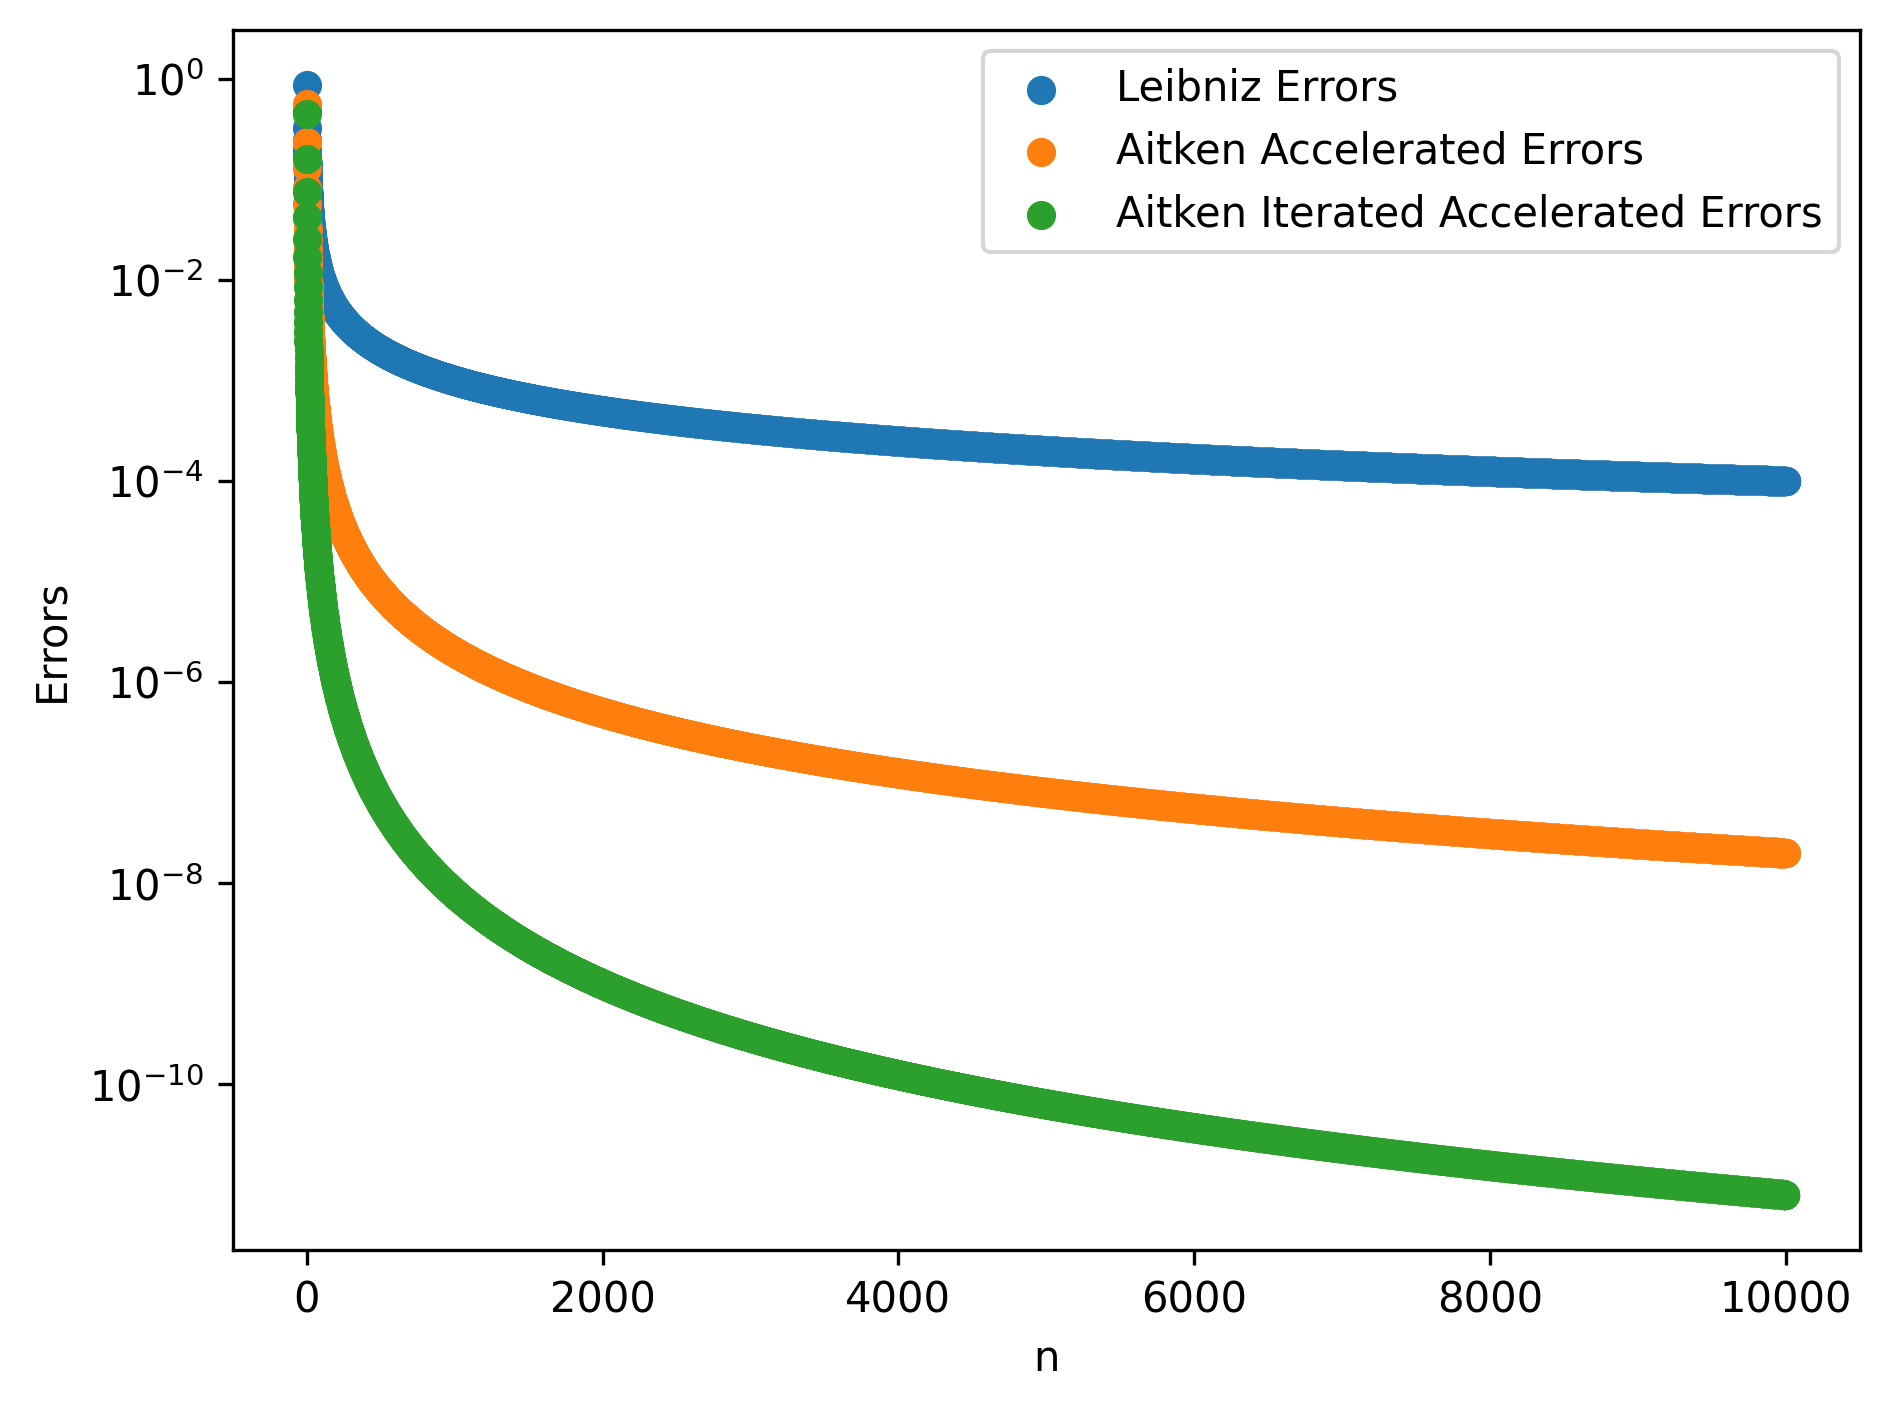

In [7]:
a_values, acc_values, acc_acc_values = np.array([]), np.array([]), np.array([])
k=0
sign = 1 # since (-1)**0 == 1
total = mpmath.mpf("0")

for i in range(2): # needs to work out three terms before the Aitken acceleration can be applied
    total += mpmath.mpf("4") * sign / (2*k + 1)
    sign *= -1 # alternate the sign of (-1)**k
    k+=1
    a_values = np.append(a_values, total)

for i in range(2): # needs to work out 5 terms before the iterated Aitken acceleration can be applied
    total += mpmath.mpf("4") * sign / (2*k + 1)
    sign *= -1 # alternate the sign of (-1)**k
    k+=1
    a_values = np.append(a_values, total)

    acc_values = np.append(acc_values, a_values[-3] - (a_values[-2] - a_values[-1])**2 / (a_values[-1] - 2*a_values[-2] + a_values[-3]))

while k<=10000:
    total += mpmath.mpf("4") * sign / (2*k + 1)
    sign *= -1 # alternate the sign of (-1)**k
    k+=1
    a_values = np.append(a_values, total)

    acc_values = np.append(acc_values, a_values[-3] - (a_values[-2] - a_values[-1])**2 / (a_values[-1] - 2*a_values[-2] + a_values[-3]))
    acc_acc_values = np.append(acc_acc_values, acc_values[-3] - (acc_values[-2] - acc_values[-1])**2 / (acc_values[-1] - 2*acc_values[-2] + acc_values[-3]))


x_values = np.linspace(0, 10000, 10001)
y_values = np.linspace(0, 9998, 9999)
z_values = np.linspace(0, 9996, 9997)

# calculate the errors
a_values, acc_values, acc_acc_values = abs(np.pi - a_values), abs(np.pi - acc_values), abs(np.pi - acc_acc_values)

fig, ax = plt.subplots()
ax.set_xlabel("n")
ax.set_ylabel("Errors")
ax.scatter(x_values, a_values, label="Leibniz Errors")
ax.set_yscale("log")
plt.gcf().set_dpi(300)
plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots()
ax.set_xlabel("n")
# ax.set_ylabel("Aitken Accelerated Errors")
ax.scatter(y_values, acc_values, label="Aitken Accelerated Errors")
plt.gcf().set_dpi(300)
plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots()
ax.set_xlabel("n")
# ax.set_ylabel("Aitken Iterated Accelerated Errors")
ax.scatter(z_values, acc_acc_values, label="Aitken Iterated Accelerated Errors")
plt.gcf().set_dpi(300)
plt.tight_layout()
plt.legend()
plt.show()

d)

In [5]:
q = (mpmath.log(acc_values[-1]) - mpmath.log(acc_values[-2])) / (mpmath.log(acc_values[-2]) - mpmath.log(acc_values[-3]))
print("q1 = "+str(q))

q = (mpmath.log(acc_acc_values[-1]) - mpmath.log(acc_acc_values[-2])) / (mpmath.log(acc_acc_values[-2]) - mpmath.log(acc_acc_values[-3]))
print("q2 = "+str(q))

q1 = 0.9997775884599972746507490187157210254506042060767937223154425291688165480778928829135071736395616669
q2 = 0.8148497541728218877134320125865856962259205766672626265299125159032788601536016808617530058437951471


The iterated Aitken accelerated sequence converges slower than the single Aitken accelecration sequence, since it has a lower order

<span style="color: SeaGreen; font-size: 32px;">Q5</span>

<span style="color: SeaGreen; font-size: 24px;">


Great stuff, though we would argue that since the order of convergence AND the rate / constant $M$ is 1, we most likely have sublinear convergence.

Would definitely advise on plotting them all on the same graph with a log scale, as shown.

Regarding the final point, the conclusion changes once you realise they're all the same (sublinear). We see that each application of acceleration is improving the error by about 8 orders of magnitude, with little effect on how it's converging (given by the plot).

</span>